# Fundamentos Estadísticos para Análisis de Datos en Ingeniería

## 1. Estadística Descriptiva Fundamental

### 1.1 Media Aritmética

La media aritmética es el estadístico de tendencia central más utilizado en ingeniería.

$$ \bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i $$

donde:
- $y_i$ son los valores individuales
- $n$ es el número total de observaciones

#### Ejemplo Práctico:
Mediciones de resistencia eléctrica (Ω): 98.2, 98.8, 98.5, 98.4, 98.6

$$ \bar{y} = \frac{98.2 + 98.8 + 98.5 + 98.4 + 98.6}{5} = 98.5\text{ Ω} $$

### 1.2 Medidas de Dispersión

#### Desviación Estándar
$$ s_y = \sqrt{\frac{\sum_{i=1}^{n} (y_i - \bar{y})^2}{n-1}} = \sqrt{\frac{S_t}{n-1}} $$

#### Varianza
$$ s_y^2 = \frac{\sum_{i=1}^{n} (y_i - \bar{y})^2}{n-1} $$

#### Coeficiente de Variación
$$ c.v. = \frac{s_y}{\bar{y}} \times 100\% $$

## 2. Distribución Normal y Análisis de Datos

### 2.1 Función de Densidad Normal
$$ f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}} $$

### 2.2 Intervalos de Confianza Importantes

1. Intervalo 68%: $\bar{y} \pm s_y$
2. Intervalo 95%: $\bar{y} \pm 2s_y$
3. Intervalo 99.7%: $\bar{y} \pm 3s_y$

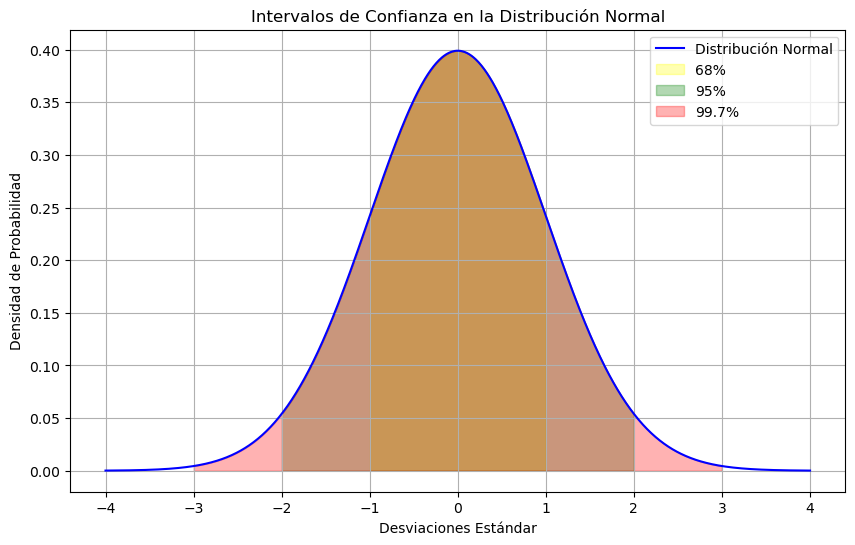

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_normal_intervals():
    x = np.linspace(-4, 4, 1000)
    y = stats.norm.pdf(x, 0, 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b-', label='Distribución Normal')
    plt.fill_between(x[abs(x)<=1], y[abs(x)<=1], color='yellow', alpha=0.3, label='68%')
    plt.fill_between(x[abs(x)<=2], y[abs(x)<=2], color='green', alpha=0.3, label='95%')
    plt.fill_between(x[abs(x)<=3], y[abs(x)<=3], color='red', alpha=0.3, label='99.7%')
    
    plt.title('Intervalos de Confianza en la Distribución Normal')
    plt.xlabel('Desviaciones Estándar')
    plt.ylabel('Densidad de Probabilidad')
    plt.legend()
    plt.grid(True)
    return plt

plt = plot_normal_intervals()
plt.show()

## 3. Inferencia Estadística

### 3.1 Estimación de Parámetros

#### Estimación Puntual
- Media muestral: $\bar{y}$ estima $\mu$
- Desviación estándar muestral: $s_y$ estima $\sigma$

#### Estimación por Intervalo
Para la media poblacional (n < 30):
$$ \bar{y} \pm t_{\alpha/2,n-1}\frac{s_y}{\sqrt{n}} $$

donde $t_{\alpha/2,n-1}$ es el valor crítico de la distribución t de Student.

### 3.2 Teorema del Límite Central

Para muestras grandes (n ≥ 30), la distribución de medias muestrales:
- Es aproximadamente normal
- Tiene media $\mu_{\bar{y}} = \mu$
- Tiene desviación estándar $\sigma_{\bar{y}} = \frac{\sigma}{\sqrt{n}}$

## 4. Aplicaciones en Control de Calidad

### 4.1 Cartas de Control

In [8]:
def crear_carta_control(datos, nombre_proceso):
    media = np.mean(datos)
    std = np.std(datos, ddof=1)
    
    lcl = media - 3*std  # Límite de control inferior
    ucl = media + 3*std  # Límite de control superior
    
    plt.figure(figsize=(12, 6))
    plt.plot(datos, 'bo-', label='Mediciones')
    plt.axhline(y=media, color='g', linestyle='-', label='Media')
    plt.axhline(y=ucl, color='r', linestyle='--', label='LSC')
    plt.axhline(y=lcl, color='r', linestyle='--', label='LIC')
    
    plt.title(f'Carta de Control para {nombre_proceso}')
    plt.xlabel('Número de Muestra')
    plt.ylabel('Valor Medido')
    plt.legend()
    plt.grid(True)
    return plt



### 4.2 Evaluación de Capacidad de Proceso

Índices de capacidad:
$$ C_p = \frac{USL - LSL}{6\sigma} $$
$$ C_{pk} = \min\left(\frac{USL-\mu}{3\sigma}, \frac{\mu-LSL}{3\sigma}\right) $$

donde:
- USL = Límite superior de especificación
- LSL = Límite inferior de especificación
- σ = Desviación estándar del proceso

## 5. Ejemplo Completo: Análisis de un Proceso de Manufactura


In [9]:
import numpy as np
from scipy import stats

# Datos de ejemplo: mediciones de diámetro de un eje
mediciones = np.random.normal(loc=50, scale=0.1, size=100)

# Análisis estadístico básico
media = np.mean(mediciones)
std_dev = np.std(mediciones, ddof=1)
cv = (std_dev/media) * 100

# Intervalos de confianza (95%)
ic_95 = stats.t.interval(alpha=0.95, df=len(mediciones)-1,
                        loc=media, scale=stats.sem(mediciones))

print(f"""
Análisis Estadístico:
--------------------
Media: {media:.4f} mm
Desviación Estándar: {std_dev:.4f} mm
Coeficiente de Variación: {cv:.2f}%
Intervalo de Confianza (95%): ({ic_95[0]:.4f}, {ic_95[1]:.4f}) mm
""")


Análisis Estadístico:
--------------------
Media: 50.0014 mm
Desviación Estándar: 0.1030 mm
Coeficiente de Variación: 0.21%
Intervalo de Confianza (95%): (49.9810, 50.0219) mm



## 6. Consideraciones Prácticas

1. **Tamaño de Muestra**
   - n < 30: Usar distribución t de Student
   - n ≥ 30: Aproximación normal válida

2. **Verificación de Normalidad**
   - Test de Shapiro-Wilk para n < 50
   - Test de Kolmogorov-Smirnov para n ≥ 50

3. **Detección de Valores Atípicos**
   - Regla empírica: ±3 desviaciones estándar
   - Método de Tukey: IQR × 1.5

## Referencias

1. Montgomery, D.C. (2009). Statistical Quality Control: A Modern Introduction (6th ed.). Wiley.
2. Walpole, R.E., Myers, R.H., Myers, S.L., & Ye, K. (2012). Probability & Statistics for Engineers & Scientists (9th ed.). Pearson.
3. Wheeler, D.J., & Chambers, D.S. (2010). Understanding Statistical Process Control (3rd ed.). SPC Press.

## Ejercicios Propuestos

1. Calcular intervalos de confianza para un conjunto de mediciones de resistencia eléctrica.
2. Desarrollar una carta de control para un proceso de manufactura.
3. Analizar la capacidad de un proceso usando datos reales.
4. Verificar la normalidad de un conjunto de datos experimentales.


Estadísticas calculadas manualmente:
media: 6.600000
varianza: 0.009435
desviacion_estandar: 0.097133
cv: 1.471709
rango: 0.380000
n: 24.000000

Estadísticas calculadas con NumPy:
media: 6.600000
varianza: 0.009435
desviacion_estandar: 0.097133
cv: 1.471709
rango: 0.380000
n: 24.000000

Intervalo de confianza 95%:
(6.558984, 6.641016)


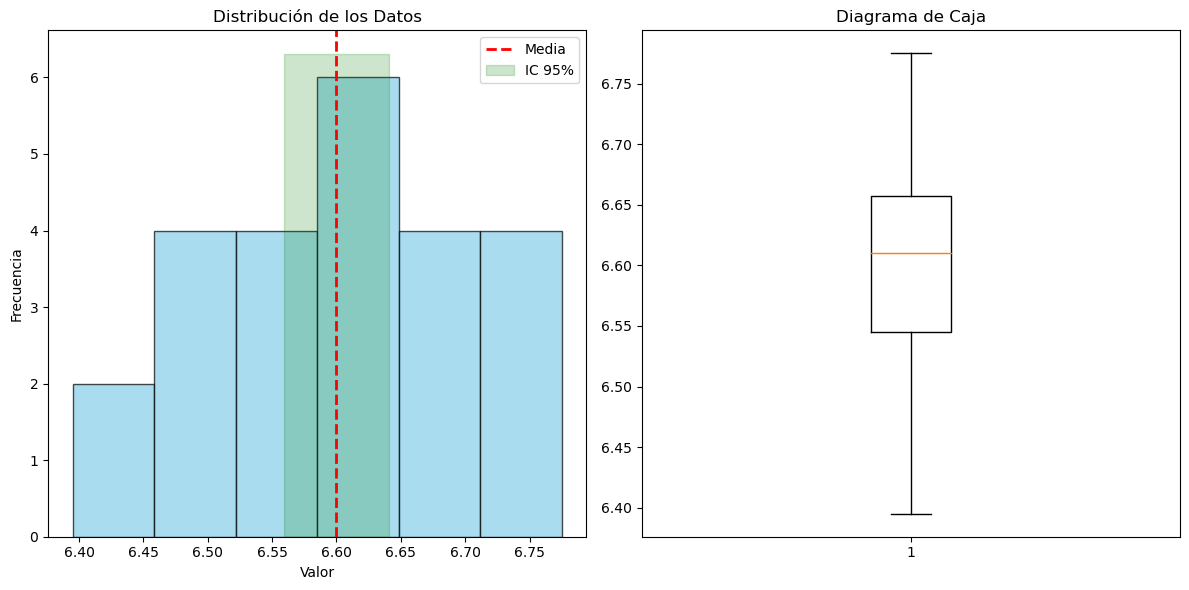

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def calcular_estadisticas_manual(datos: List[float]) -> dict:
    """
    Calcula estadísticas básicas manualmente sin usar numpy
    """
    n = len(datos)
    
    # Media aritmética
    media = sum(datos) / n
    
    # Varianza y desviación estándar
    suma_cuadrados = sum((x - media) ** 2 for x in datos)
    varianza = suma_cuadrados / (n - 1)  # n-1 para muestra
    desviacion_estandar = varianza ** 0.5
    
    # Coeficiente de variación
    cv = (desviacion_estandar / media) * 100
    
    # Rango
    rango = max(datos) - min(datos)
    
    return {
        'media': media,
        'varianza': varianza,
        'desviacion_estandar': desviacion_estandar,
        'cv': cv,
        'rango': rango,
        'n': n
    }

def calcular_intervalo_confianza(datos: List[float], nivel_confianza: float = 0.95) -> Tuple[float, float]:
    """
    Calcula el intervalo de confianza para la media
    """
    from scipy import stats
    
    media = np.mean(datos)
    n = len(datos)
    desv_est = np.std(datos, ddof=1)  # ddof=1 para muestra
    
    # Valor crítico de la distribución t de Student
    t_critico = stats.t.ppf((1 + nivel_confianza) / 2, n - 1)
    
    margen_error = t_critico * (desv_est / np.sqrt(n))
    
    return media - margen_error, media + margen_error

# Datos del ejemplo del texto (coeficiente de expansión térmica del acero)
datos = [
    6.495, 6.665, 6.755, 6.565, 6.595, 6.505, 6.625, 6.515, 6.615, 6.435,
    6.715, 6.555, 6.635, 6.625, 6.575, 6.395, 6.485, 6.715, 6.655, 6.775,
    6.555, 6.655, 6.605, 6.685
]

# Calcular estadísticas manualmente
stats_manual = calcular_estadisticas_manual(datos)

# Calcular estadísticas usando numpy (para comparación)
stats_numpy = {
    'media': np.mean(datos),
    'varianza': np.var(datos, ddof=1),
    'desviacion_estandar': np.std(datos, ddof=1),
    'cv': (np.std(datos, ddof=1) / np.mean(datos)) * 100,
    'rango': np.ptp(datos),
    'n': len(datos)
}

# Calcular intervalo de confianza al 95%
ic_inferior, ic_superior = calcular_intervalo_confianza(datos)

# Crear visualización media +
plt.figure(figsize=(12, 6))

# Histograma
plt.subplot(121)
plt.hist(datos, bins='auto', alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(stats_manual['media'], color='red', linestyle='dashed', linewidth=2, label='Media')
plt.fill_between([ic_inferior, ic_superior], plt.ylim()[0], plt.ylim()[1], 
                 color='green', alpha=0.2, label='IC 95%')
plt.title('Distribución de los Datos')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.legend()

# Box plot
plt.subplot(122)
plt.boxplot(datos)
plt.title('Diagrama de Caja')

# Imprimir resultados
print("\nEstadísticas calculadas manualmente:")
for key, value in stats_manual.items():
    print(f"{key}: {value:.6f}")

print("\nEstadísticas calculadas con NumPy:")
for key, value in stats_numpy.items():
    print(f"{key}: {value:.6f}")

print("\nIntervalo de confianza 95%:")
print(f"({ic_inferior:.6f}, {ic_superior:.6f})")

plt.tight_layout()
plt.show()